# Предсказание Риск-Скора

Модель использует полиномиальные признаки 3-й степени и PowerTransformer для предсказания риск-скора


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, PolynomialFeatures
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 8)


In [2]:
def prepare_data(train_file, test_file):
    df_train = pd.read_csv(train_file)
    df_test = pd.read_csv(test_file)
    
    df_train = df_train.dropna(subset=['RiskScore'])
    df_train = df_train[(df_train['RiskScore'] >= 0) & (df_train['RiskScore'] <= 100)]
    
    lower_q = df_train['RiskScore'].quantile(0.006)
    upper_q = df_train['RiskScore'].quantile(0.994)
    df_train = df_train[(df_train['RiskScore'] >= lower_q) & (df_train['RiskScore'] <= upper_q)].copy()
    
    target = df_train['RiskScore'].values
    ids = df_test['ID'].values
    
    df_train = df_train.drop(columns=['RiskScore', 'ApplicationDate', 'ID'], errors='ignore')
    df_test = df_test.drop(columns=['ApplicationDate', 'ID'], errors='ignore')
    
    return df_train, df_test, target, ids


def process_features(df_train, df_test):
    n = len(df_train)
    df = pd.concat([df_train, df_test], axis=0, ignore_index=True)
    
    numeric_cols = df.select_dtypes(include=np.number).columns
    for col in numeric_cols:
        median = df[col].median()
        df[col].fillna(median, inplace=True)
        q_low, q_high = df[col].quantile([0.015, 0.985])
        df[col] = df[col].clip(q_low, q_high)
    
    financial = ['AnnualIncome', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome']
    for col in financial:
        if col in df.columns:
            df[col] = np.log1p(df[col])
    
    wealth_cols = ['LoanAmount', 'NetWorth']
    for col in wealth_cols:
        if col in df.columns:
            df[col] = np.log1p(df[col])
    
    if 'EducationLevel' in df.columns:
        mapping = {'High School': 1, 'Associate': 2, 'Bachelor': 3, 'Master': 4, 'Doctorate': 5}
        df['Education_Num'] = df['EducationLevel'].map(mapping).fillna(2)
        df.drop(columns='EducationLevel', inplace=True)
    
    if 'EmploymentStatus' in df.columns:
        mapping = {'Employed': 0, 'Self-Employed': 1, 'Unemployed': 2}
        df['Employment_Num'] = df['EmploymentStatus'].map(mapping).fillna(1)
        df.drop(columns='EmploymentStatus', inplace=True)
    
    if 'CreditScore' in df.columns and 'LoanAmount' in df.columns:
        df['Credit_Loan_Ratio'] = df['CreditScore'] / (df['LoanAmount'] + 1)
    
    if 'MonthlyIncome' in df.columns and 'LoanAmount' in df.columns:
        df['Income_Loan_Ratio'] = df['MonthlyIncome'] / (df['LoanAmount'] + 1)
    
    cats = ['PaymentHistory', 'LoanPurpose', 'MaritalStatus', 'HomeOwnershipStatus']
    cats = [c for c in cats if c in df.columns]
    if cats:
        df = pd.get_dummies(df, columns=cats, drop_first=True)
    
    return df.iloc[:n].copy(), df.iloc[n:].copy()


def create_features(df_train, df_test):
    key_cols = ['CreditScore', 'MonthlyIncome', 'InterestRate', 
                'DebtToIncomeRatio', 'TotalDebtToIncomeRatio',
                'NetWorth', 'LoanAmount', 'BaseInterestRate', 'BankruptcyHistory']
    
    poly_cols = [c for c in key_cols if c in df_train.columns]
    rest_cols = [c for c in df_train.columns if c not in poly_cols]
    
    poly = PolynomialFeatures(degree=3, include_bias=False)
    train_poly = poly.fit_transform(df_train[poly_cols])
    test_poly = poly.transform(df_test[poly_cols])
    
    train_rest = df_train[rest_cols].values
    test_rest = df_test[rest_cols].values
    
    X_train = np.hstack([train_poly, train_rest])
    X_test = np.hstack([test_poly, test_rest])
    
    scaler = PowerTransformer()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    return X_train, X_test


## Загрузка и обработка данных


In [3]:
df_train, df_test, y, ids = prepare_data('train.csv', 'test.csv')
df_train, df_test = process_features(df_train, df_test)
X_train, X_test = create_features(df_train, df_test)

print(f"Загружено {len(y)} обучающих примеров, {X_train.shape[1]} признаков")


Загружено 10148 обучающих примеров, 272 признаков


## Обучение модели


In [4]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y, test_size=0.2, random_state=19)

model = LinearRegression()
model.fit(X_tr, y_tr)

y_pred_val = np.clip(model.predict(X_val), 0, 100)
val_mse = mean_squared_error(y_val, y_pred_val)

print(f"MSE на валидации: {val_mse:.4f}")


MSE на валидации: 23.0004


## Визуализация результатов


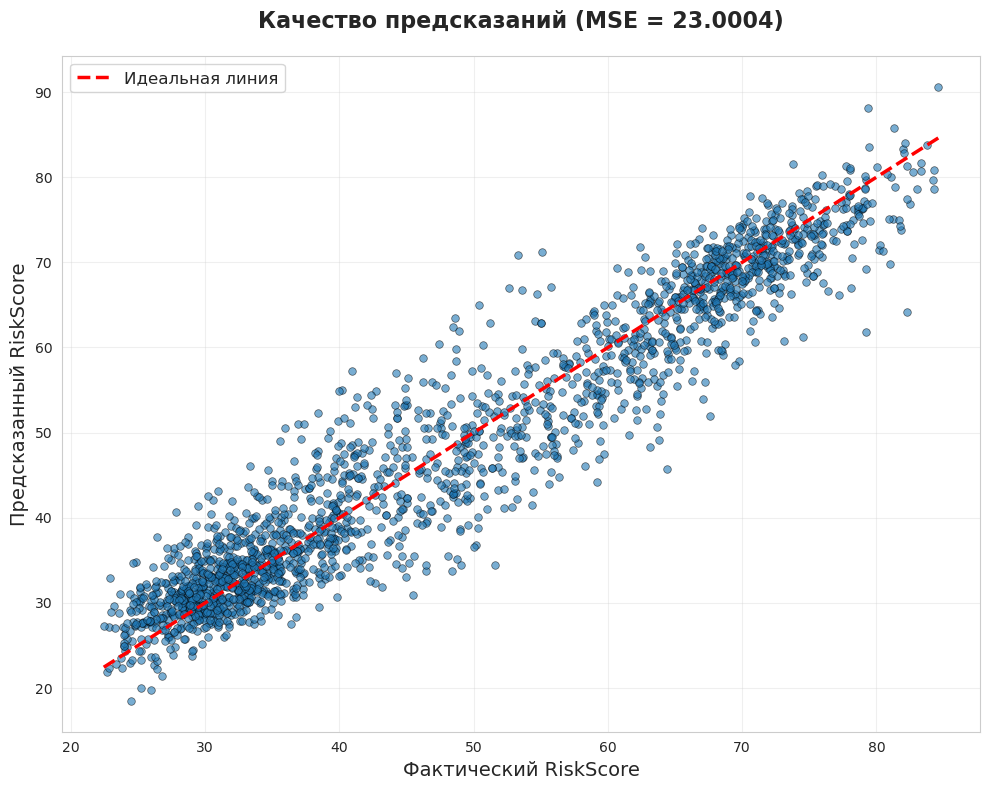


Метрики качества:
  MSE: 23.0004
  RMSE: 4.7959
  MAE: 3.6590


In [5]:
plt.figure(figsize=(10, 8))
plt.scatter(y_val, y_pred_val, alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2.5, label='Идеальная линия')

plt.xlabel('Фактический RiskScore', fontsize=14)
plt.ylabel('Предсказанный RiskScore', fontsize=14)
plt.title(f'Качество предсказаний (MSE = {val_mse:.4f})', fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

residuals = y_val - y_pred_val
print(f"\nМетрики качества:")
print(f"  MSE: {val_mse:.4f}")
print(f"  RMSE: {np.sqrt(val_mse):.4f}")
print(f"  MAE: {np.abs(residuals).mean():.4f}")


## Генерация предсказаний


In [6]:
model.fit(X_train, y)
y_pred_test = np.clip(model.predict(X_test), 0, 100)

submission = pd.DataFrame({'ID': ids, 'RiskScore': y_pred_test})
submission.to_csv('submission.csv', index=False)

print(f"Файл submission.csv сохранен ({len(submission)} предсказаний)")


Файл submission.csv сохранен (5000 предсказаний)
